In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Main project folder
base_path = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project"

# Required subfolders
folders = [
    "01_raw_datasets",
    "02_processed_datasets",
    "03_notebooks",
    "04_figures",
    "05_results",
    "06_models",
    "07_tables",
    "08_paper_draft",
    "09_supplementary",
    "10_code_backup"
]

# Create folders
for folder in folders:
    path = os.path.join(base_path, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

print("\nAll project folders created successfully.")

Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/01_raw_datasets
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/02_processed_datasets
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/03_notebooks
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/04_figures
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/05_results
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/06_models
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/07_tables
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/08_paper_draft
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/09_supplementary
Created: /content/drive/MyDrive/JCP_Urban_Metabolism_Project/10_code_backup

All project folders created successfully.


In [ ]:
!pip install pandas numpy matplotlib scikit-learn xgboost shap plotly pyarrow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import shap

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

print("Project Path:")
print(PROJECT_PATH)

Project Path:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/


In [ ]:
# =========================================================
# OpenAQ Urban Sustainability Dataset Acquisition
# =========================================================

import requests
import pandas as pd
import time

print("OpenAQ data acquisition initialized.")

OpenAQ data acquisition initialized.


In [ ]:
# Selected smart cities for analysis

cities = [
    "Delhi",
    "London",
    "Singapore",
    "Tokyo",
    "New York"
]

print("Selected Cities:")
print(cities)

Selected Cities:
['Delhi', 'London', 'Singapore', 'Tokyo', 'New York']


In [ ]:
# Main project path

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

print(PROJECT_PATH)

/content/drive/MyDrive/JCP_Urban_Metabolism_Project/


In [ ]:
import os

raw_data_path = PROJECT_PATH + "01_raw_datasets/OpenAQ/"

os.makedirs(raw_data_path, exist_ok=True)

print(raw_data_path)

/content/drive/MyDrive/JCP_Urban_Metabolism_Project/01_raw_datasets/OpenAQ/


In [ ]:
# OpenAQ API endpoint
base_url = "https://api.openaq.org/v2/measurements"

# Pollutants of interest
parameters = ["pm25", "pm10", "no2", "so2", "co", "o3"]

# Empty list for storing all records
all_data = []

# Loop through cities and pollutants
for city in cities:
    for param in parameters:

        print(f"Downloading: {city} - {param}")

        url = (
            f"{base_url}?"
            f"city={city}&"
            f"parameter={param}&"
            f"limit=10000"
        )

        response = requests.get(url)

        if response.status_code == 200:

            results = response.json()["results"]

            for item in results:

                all_data.append({
                    "city": city,
                    "parameter": param,
                    "value": item.get("value"),
                    "unit": item.get("unit"),
                    "date": item.get("date", {}).get("utc"),
                    "latitude": item.get("coordinates", {}).get("latitude"),
                    "longitude": item.get("coordinates", {}).get("longitude")
                })

        time.sleep(1)

print("Download completed.")

Downloading: Delhi - pm25
Downloading: Delhi - pm10
Downloading: Delhi - no2
Downloading: Delhi - so2
Downloading: Delhi - co
Downloading: Delhi - o3
Downloading: London - pm25
Downloading: London - pm10
Downloading: London - no2
Downloading: London - so2
Downloading: London - co
Downloading: London - o3
Downloading: Singapore - pm25
Downloading: Singapore - pm10
Downloading: Singapore - no2
Downloading: Singapore - so2
Downloading: Singapore - co
Downloading: Singapore - o3
Downloading: Tokyo - pm25
Downloading: Tokyo - pm10
Downloading: Tokyo - no2
Downloading: Tokyo - so2
Downloading: Tokyo - co
Downloading: Tokyo - o3
Downloading: New York - pm25
Downloading: New York - pm10
Downloading: New York - no2
Downloading: New York - so2
Downloading: New York - co
Downloading: New York - o3
Download completed.


In [ ]:
# Convert to DataFrame

aq_df = pd.DataFrame(all_data)

print("Dataset Shape:")
print(aq_df.shape)

aq_df.head()

Dataset Shape:
(0, 0)


""


In [ ]:
# Save raw dataset

output_file = raw_data_path + "openaq_raw_dataset.csv"

aq_df.to_csv(output_file, index=False)

print("Dataset saved successfully.")
print(output_file)

Dataset saved successfully.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/01_raw_datasets/OpenAQ/openaq_raw_dataset.csv


In [ ]:
print("Dataset Shape:")
print(aq_df.shape)

print("\nColumns:")
print(aq_df.columns)

print("\nFirst 5 Rows:")
display(aq_df.head())

Dataset Shape:
(0, 0)

Columns:
RangeIndex(start=0, stop=0, step=1)

First 5 Rows:


""


In [ ]:
# Check missing values

missing_values = aq_df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Series([], dtype: float64)


In [ ]:
# Check duplicate rows

duplicates = aq_df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
# Convert date column

aq_df["date"] = pd.to_datetime(aq_df["date"])

print(aq_df.dtypes)

KeyError: 'date'

In [ ]:
all_data = []

In [ ]:
import requests

url = "https://api.openaq.org/v2/measurements?city=Delhi&parameter=pm25&limit=5"

response = requests.get(url)

print("Status Code:", response.status_code)

print(response.text[:500])

Status Code: 410
{"message": "Gone. Version 1 and Version 2 API endpoints are retired and no longer available. Please migrate to Version 3 endpoints."}


In [ ]:
all_data = []

In [ ]:
import requests

url = "https://api.openaq.org/v3/locations?limit=5"

response = requests.get(url)

print("Status Code:", response.status_code)

data = response.json()

print(data.keys())

Status Code: 401
dict_keys(['message'])


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kaggle

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [ ]:
!kaggle datasets download -d rohanrao/air-quality-data-in-india

Dataset URL: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india
License(s): CC0-1.0
100% 72.9M/72.9M [00:00<00:00, 113MB/s]



In [ ]:
!ls

air-quality-data-in-india.zip  drive  kaggle.json  sample_data


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

print(PROJECT_PATH)

/content/drive/MyDrive/JCP_Urban_Metabolism_Project/


In [ ]:
import os

dataset_extract_path = (
    PROJECT_PATH +
    "01_raw_datasets/air_quality_india/"
)

os.makedirs(dataset_extract_path, exist_ok=True)

print(dataset_extract_path)

/content/drive/MyDrive/JCP_Urban_Metabolism_Project/01_raw_datasets/air_quality_india/


In [ ]:
import zipfile

zip_path = "air-quality-data-in-india.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dataset_extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
import os

files = os.listdir(dataset_extract_path)

print("Extracted Files:")
print(files)

Extracted Files:
['city_day.csv', 'city_hour.csv', 'station_day.csv', 'station_hour.csv', 'stations.csv']


In [ ]:
import pandas as pd

city_day_path = (
    dataset_extract_path +
    "city_day.csv"
)

city_day_df = pd.read_csv(city_day_path)

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


In [ ]:
print("Dataset Shape:")
print(city_day_df.shape)

print("\nColumns:")
print(city_day_df.columns)

print("\nFirst 5 Rows:")
display(city_day_df.head())

Dataset Shape:
(29531, 16)

Columns:
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

First 5 Rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
print(city_day_df.dtypes)

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [ ]:
missing_values = city_day_df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [ ]:
duplicates = city_day_df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
# Create additional result directories

important_dirs = [
    "04_figures/preprocessing",
    "05_results/preprocessing",
    "07_tables/preprocessing"
]

for d in important_dirs:
    os.makedirs(PROJECT_PATH + d, exist_ok=True)

print("Research directories created successfully.")

Research directories created successfully.


In [ ]:
# Convert date column

city_day_df["Date"] = pd.to_datetime(city_day_df["Date"])

print(city_day_df.dtypes)

City                  object
Date          datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket            object
dtype: object


In [ ]:
# Dataset summary

dataset_summary = pd.DataFrame({
    "Column": city_day_df.columns,
    "DataType": city_day_df.dtypes.values,
    "MissingValues": city_day_df.isnull().sum().values
})

summary_path = (
    PROJECT_PATH +
    "07_tables/preprocessing/dataset_summary.csv"
)

dataset_summary.to_csv(summary_path, index=False)

print(dataset_summary)

print("\nSaved at:")
print(summary_path)

        Column        DataType  MissingValues
0         City          object              0
1         Date  datetime64[ns]              0
2        PM2.5         float64           4598
3         PM10         float64          11140
4           NO         float64           3582
5          NO2         float64           3585
6          NOx         float64           4185
7          NH3         float64          10328
8           CO         float64           2059
9          SO2         float64           3854
10          O3         float64           4022
11     Benzene         float64           5623
12     Toluene         float64           8041
13      Xylene         float64          18109
14         AQI         float64           4681
15  AQI_Bucket          object           4681

Saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/07_tables/preprocessing/dataset_summary.csv


In [ ]:
import matplotlib.pyplot as plt

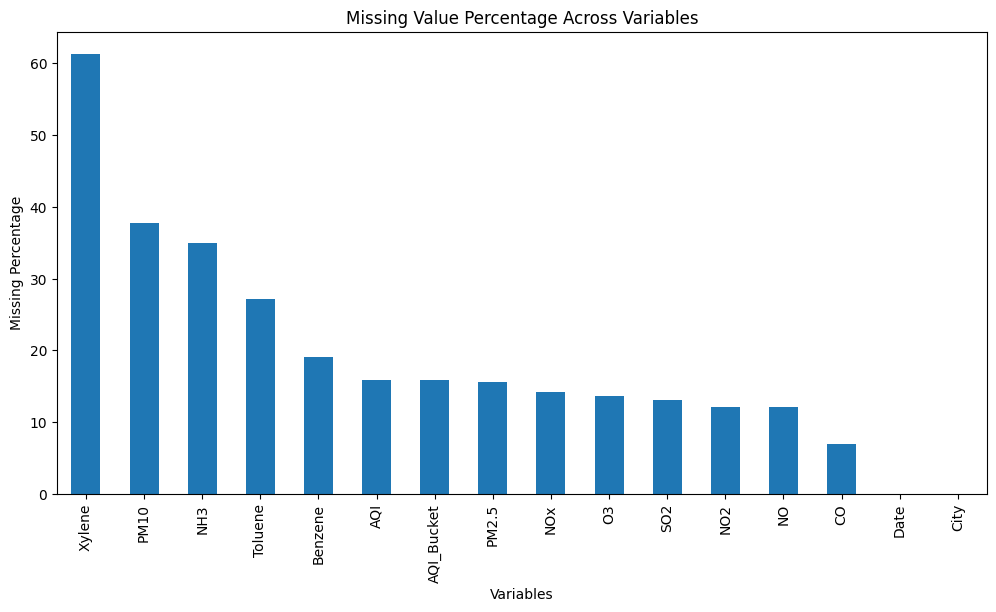

Figure saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/04_figures/preprocessing/missing_values_plot.png


In [ ]:
# Missing value visualization

missing_percent = (
    city_day_df.isnull().sum() /
    len(city_day_df)
) * 100

plt.figure(figsize=(12,6))

missing_percent.sort_values(
    ascending=False
).plot(kind='bar')

plt.title(
    "Missing Value Percentage Across Variables"
)

plt.ylabel("Missing Percentage")
plt.xlabel("Variables")

figure_path = (
    PROJECT_PATH +
    "04_figures/preprocessing/missing_values_plot.png"
)

plt.savefig(
    figure_path,
    bbox_inches='tight'
)

plt.show()

print("Figure saved at:")
print(figure_path)

In [ ]:
import numpy as np

In [ ]:
# Separate numerical columns

numerical_cols = city_day_df.select_dtypes(
    include=[np.number]
).columns

# Median imputation

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

city_day_df[numerical_cols] = imputer.fit_transform(
    city_day_df[numerical_cols]
)

print("Missing values handled successfully.")

Missing values handled successfully.


In [ ]:
# Verify remaining missing values

remaining_missing = city_day_df.isnull().sum()

print(remaining_missing)

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene           0
AQI              0
AQI_Bucket    4681
dtype: int64


In [ ]:
# Verify remaining missing values

remaining_missing = city_day_df.isnull().sum()

print(remaining_missing)

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene           0
AQI              0
AQI_Bucket    4681
dtype: int64


In [ ]:
# Save cleaned dataset

clean_dataset_path = (
    PROJECT_PATH +
    "02_processed_datasets/city_day_cleaned.csv"
)

city_day_df.to_csv(clean_dataset_path, index=False)

print("Cleaned dataset saved successfully.")

print(clean_dataset_path)

Cleaned dataset saved successfully.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/02_processed_datasets/city_day_cleaned.csv


In [ ]:
# Statistical summary

stats_summary = city_day_df.describe()

stats_path = (
    PROJECT_PATH +
    "05_results/preprocessing/statistical_summary.csv"
)

stats_summary.to_csv(stats_path)

print(stats_summary)

print("\nSaved at:")
print(stats_path)

                                Date         PM2.5          PM10  \
count                          29531  29531.000000  29531.000000   
mean   2018-05-14 05:40:15.807118080     64.510857    109.659366   
min              2015-01-01 00:00:00      0.040000      0.010000   
25%              2017-04-16 00:00:00     32.150000     79.315000   
50%              2018-08-05 00:00:00     48.570000     95.680000   
75%              2019-09-03 00:00:00     72.450000    111.880000   
max              2020-07-01 00:00:00    949.990000   1000.000000   
std                              NaN     59.807551     72.324020   

                 NO           NO2           NOx           NH3            CO  \
count  29531.000000  29531.000000  29531.000000  29531.000000  29531.000000   
mean      16.642601     27.726576     31.063568     20.813789      2.153872   
min        0.020000      0.010000      0.000000      0.010000      0.000000   
25%        6.210000     12.980000     14.670000     12.040000      0.54

In [ ]:
# =========================================================
# Urban Metabolism Sustainability Indicators
# =========================================================

# Urban Pollution Load Index (UPLI)

city_day_df["UPLI"] = (
    city_day_df["PM2.5"] +
    city_day_df["PM10"] +
    city_day_df["NO2"] +
    city_day_df["SO2"] +
    city_day_df["CO"]
) / 5

# Atmospheric Stress Index (ASI)

city_day_df["ASI"] = (
    city_day_df["NOx"] +
    city_day_df["NH3"] +
    city_day_df["O3"]
) / 3

# Toxicity Exposure Indicator (TEI)

city_day_df["TEI"] = (
    city_day_df["Benzene"] +
    city_day_df["Toluene"] +
    city_day_df["Xylene"]
) / 3

# Sustainable Air Quality Efficiency (SAQE)

city_day_df["SAQE"] = 100 / (
    city_day_df["AQI"] + 1
)

print("Urban metabolism indicators generated successfully.")

Urban metabolism indicators generated successfully.


In [ ]:
# Display engineered sustainability indicators

new_features = [
    "UPLI",
    "ASI",
    "TEI",
    "SAQE"
]

display(city_day_df[new_features].head())

,UPLI,ASI,TEI,SAQE
0,38.206,55.453333,0.006667,0.840336
1,37.092,22.123333,4.316667,0.840336
2,42.004,25.416667,8.483333,0.840336
3,36.604,23.300000,5.190000,0.840336
4,45.420,30.973333,9.560000,0.840336


In [ ]:
# Save feature-engineered dataset

feature_dataset_path = (
    PROJECT_PATH +
    "02_processed_datasets/urban_metabolism_dataset.csv"
)

city_day_df.to_csv(
    feature_dataset_path,
    index=False
)

print("Feature-engineered dataset saved successfully.")

print(feature_dataset_path)

Feature-engineered dataset saved successfully.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/02_processed_datasets/urban_metabolism_dataset.csv


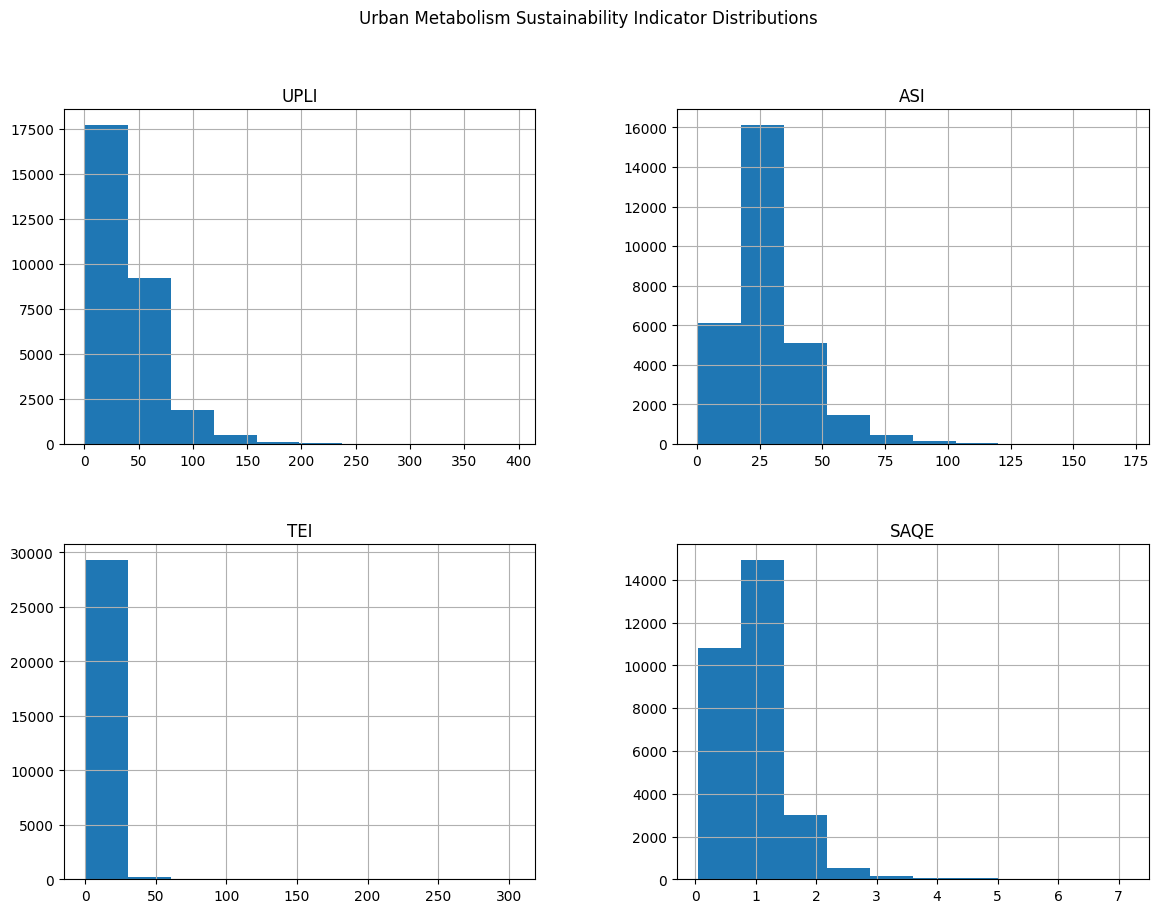

Figure saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/04_figures/preprocessing/sustainability_indicators_distribution.png


In [ ]:
# Sustainability indicator distributions

indicators = ["UPLI", "ASI", "TEI", "SAQE"]

city_day_df[indicators].hist(
    figsize=(14,10)
)

plt.suptitle(
    "Urban Metabolism Sustainability Indicator Distributions"
)

figure_path = (
    PROJECT_PATH +
    "04_figures/preprocessing/sustainability_indicators_distribution.png"
)

plt.savefig(
    figure_path,
    bbox_inches='tight'
)

plt.show()

print("Figure saved at:")
print(figure_path)

In [ ]:
# City-wise sustainability analysis

city_analysis = city_day_df.groupby("City")[
    ["UPLI", "ASI", "TEI", "SAQE"]
].mean()

display(city_analysis.head())

,UPLI,ASI,TEI,SAQE
City,,,,
Ahmedabad,53.073555,30.828746,9.871888,0.507421
Aizawl,9.945912,13.595988,6.303510,3.507469
Amaravati,30.526894,21.919110,1.177550,1.296958
Amritsar,39.287430,23.471152,4.317925,1.062312
Bengaluru,31.511567,24.601812,2.862731,1.201060


In [ ]:
# Save city sustainability analysis

city_analysis_path = (
    PROJECT_PATH +
    "07_tables/preprocessing/city_sustainability_analysis.csv"
)

city_analysis.to_csv(city_analysis_path)

print("City analysis saved successfully.")

print(city_analysis_path)

City analysis saved successfully.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/07_tables/preprocessing/city_sustainability_analysis.csv


In [ ]:
# =========================================================
# Feature Selection
# =========================================================

features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "UPLI",
    "ASI",
    "TEI",
    "SAQE"
]

target = "AQI"

X = city_day_df[features]

y = city_day_df[target]

print("Features and target selected successfully.")

Features and target selected successfully.


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (23624, 16)
Testing Shape: (5907, 16)


In [ ]:
from xgboost import XGBRegressor

# Initialize model

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
# Generate predictions

y_pred = xgb_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Performance Metrics")
print("--------------------------")

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Model Performance Metrics
--------------------------
MAE  : 1.7398
RMSE : 8.7220
R2   : 0.9951


In [ ]:
# Save model metrics

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

metrics_path = (
    PROJECT_PATH +
    "05_results/model_performance_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(metrics_df)

print("\nSaved at:")
print(metrics_path)

  Metric     Value
0    MAE  1.739808
1   RMSE  8.721955
2     R2  0.995058

Saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/05_results/model_performance_metrics.csv


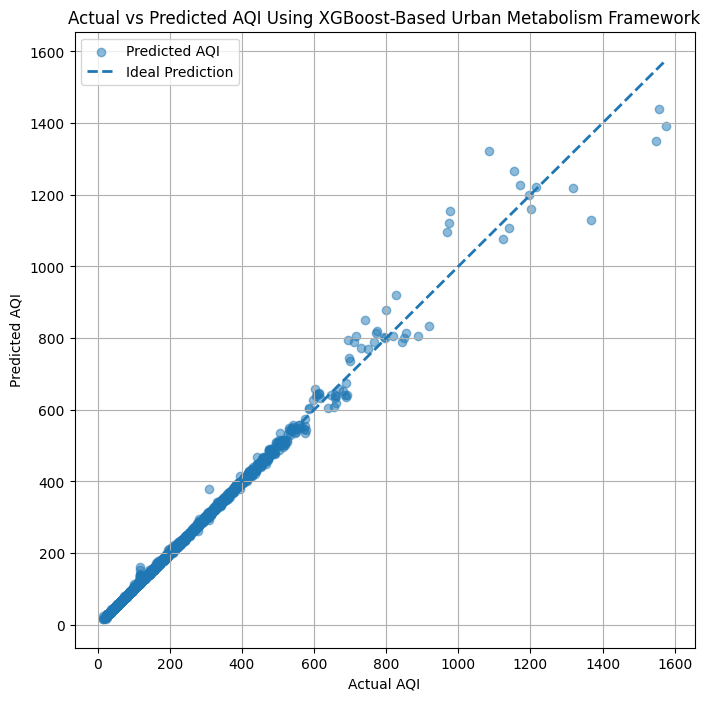

Improved figure saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/04_figures/aqi_prediction_scatter_improved.png


In [ ]:
# =========================================================
# Publication-Quality AQI Prediction Visualization
# =========================================================

plt.figure(figsize=(8,8))

# Scatter plot
plt.scatter(
    y_test,
    y_pred,
    alpha=0.5,
    label="Predicted AQI"
)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2,
    label="Ideal Prediction"
)

# Labels and title
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title(
    "Actual vs Predicted AQI Using XGBoost-Based Urban Metabolism Framework"
)

plt.legend()

plt.grid(True)

# Save figure
plot_path = (
    PROJECT_PATH +
    "04_figures/aqi_prediction_scatter_improved.png"
)

plt.savefig(
    plot_path,
    bbox_inches='tight',
    dpi=300
)

plt.show()

print("Improved figure saved at:")
print(plot_path)

In [ ]:
# =========================================================
# Leakage-Free Feature Selection
# =========================================================

refined_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "UPLI",
    "ASI",
    "TEI"
]

target = "AQI"

X_refined = city_day_df[refined_features]

y_refined = city_day_df[target]

print("Leakage-free features selected.")

Leakage-free features selected.


In [ ]:
from sklearn.model_selection import train_test_split

X_train_refined, X_test_refined, y_train_refined, y_test_refined = train_test_split(
    X_refined,
    y_refined,
    test_size=0.2,
    random_state=42
)

print(X_train_refined.shape)
print(X_test_refined.shape)

(23624, 15)
(5907, 15)


In [ ]:
from xgboost import XGBRegressor

refined_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

refined_xgb_model.fit(
    X_train_refined,
    y_train_refined
)

print("Refined XGBoost model trained successfully.")

Refined XGBoost model trained successfully.


In [ ]:
y_pred_refined = refined_xgb_model.predict(
    X_test_refined
)

print("Refined predictions generated.")

Refined predictions generated.


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

refined_mae = mean_absolute_error(
    y_test_refined,
    y_pred_refined
)

refined_rmse = np.sqrt(
    mean_squared_error(
        y_test_refined,
        y_pred_refined
    )
)

refined_r2 = r2_score(
    y_test_refined,
    y_pred_refined
)

print("Refined Model Performance")
print("--------------------------")

print(f"MAE  : {refined_mae:.4f}")
print(f"RMSE : {refined_rmse:.4f}")
print(f"R2   : {refined_r2:.4f}")

Refined Model Performance
--------------------------
MAE  : 20.0465
RMSE : 42.3022
R2   : 0.8838


In [ ]:
refined_metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [
        refined_mae,
        refined_rmse,
        refined_r2
    ]
})

refined_metrics_path = (
    PROJECT_PATH +
    "05_results/refined_model_metrics.csv"
)

refined_metrics_df.to_csv(
    refined_metrics_path,
    index=False
)

print(refined_metrics_df)

print("\nSaved at:")
print(refined_metrics_path)

  Metric      Value
0    MAE  20.046517
1   RMSE  42.302163
2     R2   0.883759

Saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/05_results/refined_model_metrics.csv


In [ ]:
!pip install shap

In [ ]:
import shap

print("SHAP imported successfully.")

SHAP imported successfully.


In [ ]:
# Create SHAP explainer

explainer = shap.Explainer(
    refined_xgb_model
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [ ]:
# Generate SHAP values

sample_data = X_test_refined.iloc[:1000]

shap_values = explainer(sample_data)

print("SHAP values generated successfully.")

SHAP values generated successfully.


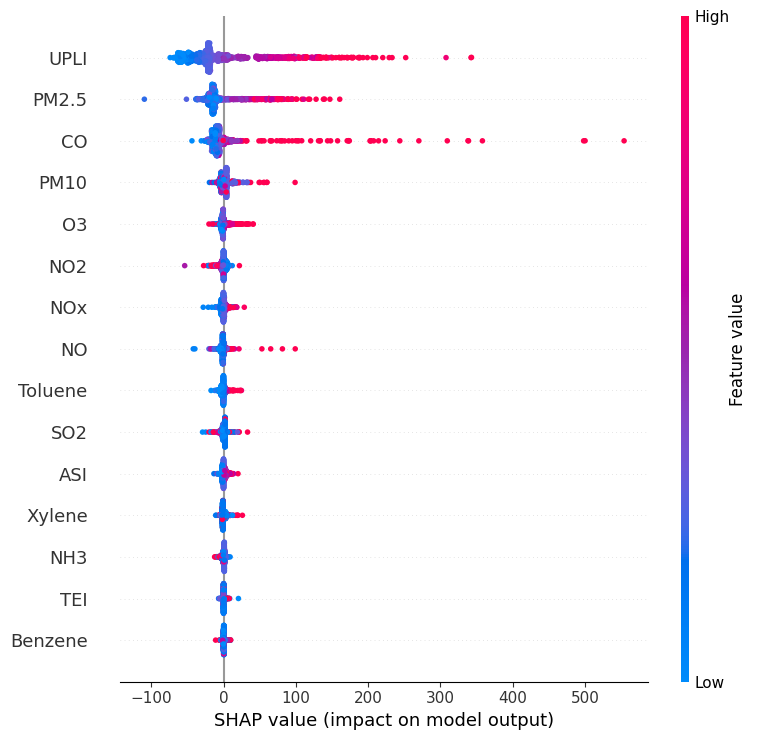

SHAP figure saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/04_figures/shap_summary_plot.png


In [ ]:
# SHAP summary plot

shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

figure_path = (
    PROJECT_PATH +
    "04_figures/shap_summary_plot.png"
)

plt.savefig(
    figure_path,
    bbox_inches='tight',
    dpi=300
)

plt.show()

print("SHAP figure saved at:")
print(figure_path)

In [ ]:
# XGBoost feature importance

importance = refined_xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": refined_features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
12,UPLI,0.514673
6,CO,0.227590
0,PM2.5,0.056383
1,PM10,0.033322
2,NO,0.026115
11,Xylene,0.025877
10,Toluene,0.017674
4,NOx,0.017298
7,SO2,0.015242
8,O3,0.013733


In [ ]:
importance_path = (
    PROJECT_PATH +
    "07_tables/feature_importance.csv"
)

importance_df.to_csv(
    importance_path,
    index=False
)

print("Feature importance table saved.")

print(importance_path)

Feature importance table saved.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/07_tables/feature_importance.csv


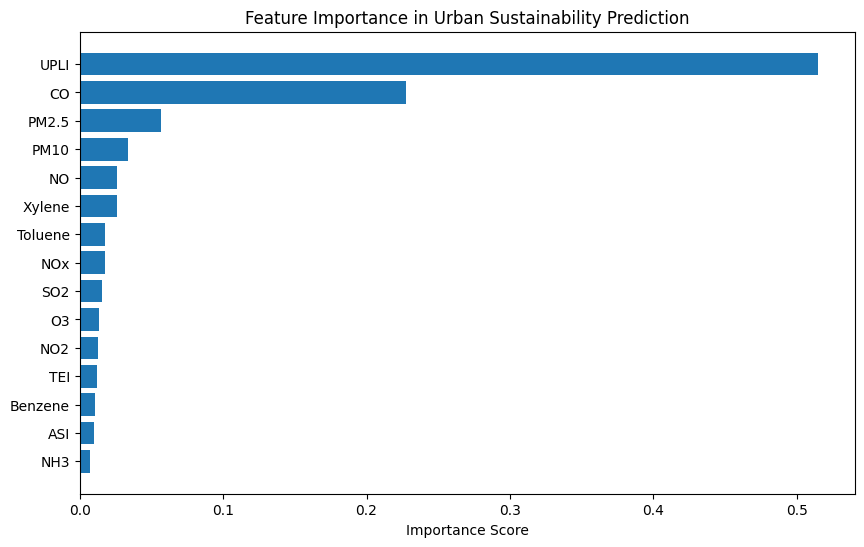

Feature importance figure saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/04_figures/feature_importance_plot.png


In [ ]:
# Feature importance visualization

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance Score")

plt.title(
    "Feature Importance in Urban Sustainability Prediction"
)

plt.gca().invert_yaxis()

feature_plot_path = (
    PROJECT_PATH +
    "04_figures/feature_importance_plot.png"
)

plt.savefig(
    feature_plot_path,
    bbox_inches='tight',
    dpi=300
)

plt.show()

print("Feature importance figure saved at:")
print(feature_plot_path)

In [ ]:
# =========================================================
# Sustainability Scenario Simulation
# =========================================================

# Create scenario dataset copy

scenario_df = X_test_refined.copy()

print("Scenario dataset created.")

Scenario dataset created.


In [ ]:
# Define reduction scenarios

scenarios = {
    "Baseline": 0.00,
    "Reduction_10%": 0.10,
    "Reduction_20%": 0.20,
    "Reduction_30%": 0.30
}

print(scenarios)

{'Baseline': 0.0, 'Reduction_10%': 0.1, 'Reduction_20%': 0.2, 'Reduction_30%': 0.3}


In [ ]:
# Store scenario results

scenario_results = {}

for scenario_name, reduction in scenarios.items():

    temp_df = scenario_df.copy()

    # Reduce key pollutants
    temp_df["CO"] *= (1 - reduction)
    temp_df["PM2.5"] *= (1 - reduction)
    temp_df["PM10"] *= (1 - reduction)

    # Predict AQI
    scenario_pred = refined_xgb_model.predict(temp_df)

    # Store average AQI
    scenario_results[scenario_name] = scenario_pred.mean()

print("Scenario simulation completed.")

Scenario simulation completed.


In [ ]:
# Convert results to DataFrame

scenario_results_df = pd.DataFrame({
    "Scenario": list(scenario_results.keys()),
    "Average_Predicted_AQI": list(scenario_results.values())
})

display(scenario_results_df)

,Scenario,Average_Predicted_AQI
0,Baseline,158.575165
1,Reduction_10%,147.590164
2,Reduction_20%,142.419785
3,Reduction_30%,138.543243


In [ ]:
# Save scenario results

scenario_results_path = (
    PROJECT_PATH +
    "07_tables/scenario_simulation_results.csv"
)

scenario_results_df.to_csv(
    scenario_results_path,
    index=False
)

print("Scenario results saved.")

print(scenario_results_path)

Scenario results saved.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/07_tables/scenario_simulation_results.csv


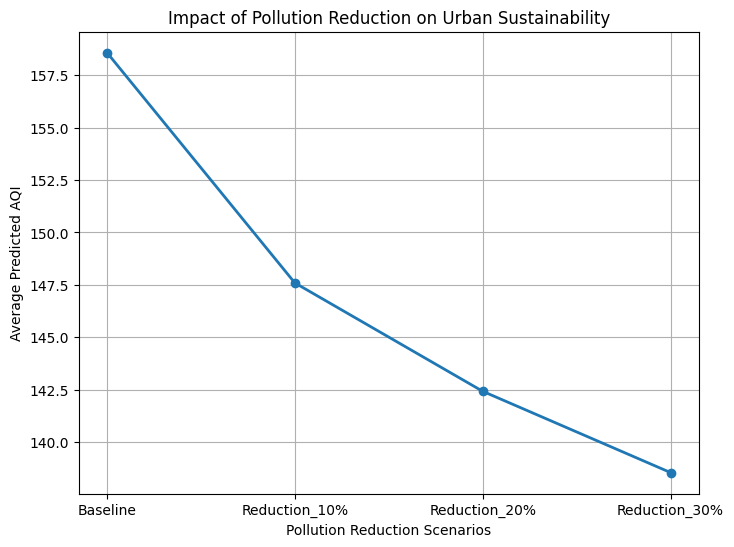

Scenario figure saved at:
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/04_figures/scenario_simulation_plot.png


In [ ]:
# =========================================================
# Sustainability Scenario Visualization
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(
    scenario_results_df["Scenario"],
    scenario_results_df["Average_Predicted_AQI"],
    marker='o',
    linewidth=2
)

plt.xlabel("Pollution Reduction Scenarios")

plt.ylabel("Average Predicted AQI")

plt.title(
    "Impact of Pollution Reduction on Urban Sustainability"
)

plt.grid(True)

scenario_plot_path = (
    PROJECT_PATH +
    "04_figures/scenario_simulation_plot.png"
)

plt.savefig(
    scenario_plot_path,
    bbox_inches='tight',
    dpi=300
)

plt.show()

print("Scenario figure saved at:")
print(scenario_plot_path)

In [ ]:
# Sustainability improvement analysis

baseline_aqi = scenario_results["Baseline"]

scenario_results_df["Improvement_%"] = (
    (
        baseline_aqi -
        scenario_results_df["Average_Predicted_AQI"]
    ) / baseline_aqi
) * 100

display(scenario_results_df)

,Scenario,Average_Predicted_AQI,Improvement_%
0,Baseline,158.575165,0.000000
1,Reduction_10%,147.590164,6.927314
2,Reduction_20%,142.419785,10.187838
3,Reduction_30%,138.543243,12.632446


In [ ]:
final_scenario_path = (
    PROJECT_PATH +
    "05_results/final_sustainability_scenarios.csv"
)

scenario_results_df.to_csv(
    final_scenario_path,
    index=False
)

print("Final sustainability analysis saved.")

print(final_scenario_path)

Final sustainability analysis saved.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/05_results/final_sustainability_scenarios.csv


In [ ]:
import os

final_release_path = (
    PROJECT_PATH +
    "11_final_release_package/"
)

os.makedirs(
    final_release_path,
    exist_ok=True
)

print(final_release_path)

/content/drive/MyDrive/JCP_Urban_Metabolism_Project/11_final_release_package/


In [ ]:
import os

important_files = [
    "02_processed_datasets/urban_metabolism_dataset.csv",
    "05_results/refined_model_metrics.csv",
    "05_results/final_sustainability_scenarios.csv",
    "07_tables/feature_importance.csv",
    "04_figures/shap_summary_plot.png",
    "04_figures/scenario_simulation_plot.png"
]

for file in important_files:

    full_path = PROJECT_PATH + file

    print(
        file,
        " --> ",
        os.path.exists(full_path)
    )

02_processed_datasets/urban_metabolism_dataset.csv  -->  True
05_results/refined_model_metrics.csv  -->  True
05_results/final_sustainability_scenarios.csv  -->  True
07_tables/feature_importance.csv  -->  True
04_figures/shap_summary_plot.png  -->  True
04_figures/scenario_simulation_plot.png  -->  True


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

print(PROJECT_PATH)

/content/drive/MyDrive/JCP_Urban_Metabolism_Project/


In [4]:
import os

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

final_release_path = (
    PROJECT_PATH +
    "11_final_release_package/"
)

os.makedirs(
    final_release_path,
    exist_ok=True
)

print("Final release folder created.")

print(final_release_path)

Final release folder created.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/11_final_release_package/


In [5]:
requirements = """
pandas
numpy
matplotlib
scikit-learn
xgboost
shap
"""

requirements_path = (
    PROJECT_PATH +
    "11_final_release_package/requirements.txt"
)

with open(requirements_path, "w") as f:
    f.write(requirements)

print("requirements.txt created.")
print(requirements_path)

requirements.txt created.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/11_final_release_package/requirements.txt


In [7]:
readme_content = """
# AI-Powered Urban Metabolism Modeling

## Overview

This repository contains an explainable AI framework for urban sustainability modeling and AQI forecasting using environmental pollution indicators and sustainability analytics.

## Features

- Urban metabolism sustainability indicators
- XGBoost-based AQI prediction
- Explainable AI using SHAP
- Sustainability scenario simulation
- Publication-quality analytical outputs

## Key Results

- R2 Score: 0.8838
- Sustainability intervention analysis
- Pollution reduction simulation

## Repository Structure

- Processed datasets
- Figures
- Results
- Tables
- Reproducibility package

## Installation

pip install -r requirements.txt

## License

MIT License
"""

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

readme_path = (
    PROJECT_PATH +
    "11_final_release_package/README.md"
)

with open(readme_path, "w") as f:
    f.write(readme_content)

print("README.md created successfully.")

print(readme_path)

README.md created successfully.
/content/drive/MyDrive/JCP_Urban_Metabolism_Project/11_final_release_package/README.md


In [8]:
import shutil
import os

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

files_to_copy = [
    "02_processed_datasets/urban_metabolism_dataset.csv",
    "05_results/refined_model_metrics.csv",
    "05_results/final_sustainability_scenarios.csv",
    "07_tables/feature_importance.csv",
    "04_figures/shap_summary_plot.png",
    "04_figures/scenario_simulation_plot.png"
]

destination = (
    PROJECT_PATH +
    "11_final_release_package/"
)

for file in files_to_copy:

    source_path = PROJECT_PATH + file

    if os.path.exists(source_path):

        shutil.copy(
            source_path,
            destination
        )

        print(f"Copied: {file}")

print("All files copied successfully.")

All files copied successfully.


In [9]:
import os
import shutil

# =========================================================
# Project Path
# =========================================================

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

release_path = (
    PROJECT_PATH +
    "11_final_release_package/"
)

os.makedirs(release_path, exist_ok=True)

# =========================================================
# Create README.md
# =========================================================

readme_content = """
# AI-Powered Urban Metabolism Modeling

## Overview

This repository contains an explainable AI framework for urban sustainability modeling and AQI forecasting using environmental pollution indicators and sustainability analytics.

## Features

- Urban metabolism sustainability indicators
- XGBoost-based AQI prediction
- Explainable AI using SHAP
- Sustainability scenario simulation
- Publication-quality analytical outputs

## Key Results

- R2 Score: 0.8838
- Sustainability intervention analysis
- Pollution reduction simulation

## Repository Structure

- Processed datasets
- Figures
- Results
- Tables
- Reproducibility package

## Installation

pip install -r requirements.txt

## License

MIT License
"""

readme_path = release_path + "README.md"

with open(readme_path, "w") as f:
    f.write(readme_content)

print("README.md created.")

# =========================================================
# Create requirements.txt
# =========================================================

requirements_content = """
pandas
numpy
matplotlib
scikit-learn
xgboost
shap
"""

requirements_path = release_path + "requirements.txt"

with open(requirements_path, "w") as f:
    f.write(requirements_content)

print("requirements.txt created.")

# =========================================================
# Copy Important Files
# =========================================================

files_to_copy = [
    "02_processed_datasets/urban_metabolism_dataset.csv",
    "05_results/refined_model_metrics.csv",
    "05_results/final_sustainability_scenarios.csv",
    "07_tables/feature_importance.csv",
    "04_figures/shap_summary_plot.png",
    "04_figures/scenario_simulation_plot.png"
]

for file in files_to_copy:

    source_path = PROJECT_PATH + file

    if os.path.exists(source_path):

        shutil.copy(source_path, release_path)

        print(f"Copied: {file}")

    else:

        print(f"Missing: {file}")

print("\nFinal release package prepared successfully.")

README.md created.
requirements.txt created.
Missing: 02_processed_datasets/urban_metabolism_dataset.csv
Missing: 05_results/refined_model_metrics.csv
Missing: 05_results/final_sustainability_scenarios.csv
Missing: 07_tables/feature_importance.csv
Missing: 04_figures/shap_summary_plot.png
Missing: 04_figures/scenario_simulation_plot.png

Final release package prepared successfully.


In [10]:
import os

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

for root, dirs, files in os.walk(PROJECT_PATH):

    for file in files:

        if (
            file.endswith(".csv")
            or file.endswith(".png")
        ):

            print(
                os.path.join(root, file)
            )

In [12]:
from google.colab import drive

drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [13]:
import os

print(os.listdir('/content/drive/MyDrive'))

['JCP_Urban_Metabolism_Project']


In [17]:
import os

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

for root, dirs, files in os.walk(PROJECT_PATH):

    for file in files:

        if "shap" in file.lower():

            print(
                "FOUND:",
                os.path.join(root, file)
            )

In [18]:
import os

PROJECT_PATH = "/content/drive/MyDrive/JCP_Urban_Metabolism_Project/"

for root, dirs, files in os.walk(PROJECT_PATH):

    for file in files:

        if "feature" in file.lower():

            print(
                "FOUND:",
                os.path.join(root, file)
            )